# 🖥️ PC Gamer Price Predictor — pipeline completo

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Loren1z9o/Price-Predictory-Hardware-/blob/main/PC_Gamer_Price_Predictor.ipynb)

Regressão supervisionada do **preço (R$)** de um PC gamer a partir de 8 componentes, comparando
**Regressão Linear Múltipla** (Modelo A) e **KNN** (Modelo B).

Machine Learning Clássico · Engenharia de Computação · UniSATC 2026
Lorenzo Sartori, João Gustavo e Lucas Rodrigues Vigarani · Prof. Dr. Rodrigo Ramos Silva

**Ordem do pipeline (sem vazamento de dados):** dados → split 70/15/15 → EDA no treino →
Linear → KNN (GridSearchCV) → seleção pela validação → teste usado uma única vez.

In [1]:
# Configuração: no Colab, baixa o repositório; localmente, usa os arquivos da pasta
import os
if not os.path.exists("pc_gamer_ml.py"):
    !git clone -q https://github.com/Loren1z9o/Price-Predictory-Hardware-.git
    %cd Price-Predictory-Hardware-

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
import pc_gamer_ml as ml

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
brl = lambda v: f"R$ {v:,.0f}".replace(",", ".")

## 1. Dados
3.000 builds geradas a partir de um catálogo com **preços reais** (hardwarebarato.com, KaBuM, Pichau, ago/2026),
respeitando socket e DDR. Preço = soma das peças × variação de mercado aleatória de **±8%**.
Nenhuma estatística é calculada nesta etapa.

In [2]:
df = ml.gerar_dataset(3000)
print("Formato:", df.shape)
print("Peças por categoria:", {k: len(v) for k, v in ml.CATALOGO.items()})
df.head()

Formato: (3000, 10)
Peças por categoria: {'cpu': 16, 'mobo': 11, 'ram': 8, 'gpu': 14, 'ssd': 7, 'fonte': 6, 'cooler': 5, 'gabinete': 5}


,cpu,mobo,ram,gpu,ssd,fonte,cooler,gabinete,tier,preco
0,Intel i5-14600KF,ASUS TUF B760M-Plus DDR5,DDR5 32GB 6000MHz RGB,RTX 5080,WD Blue SN580 1TB,Corsair RM1000x Gold,Thermalright Peerless Assassin,NZXT H5 Flow,high,"15,663.71"
1,Intel i5-14600KF,MSI MAG Z790 Tomahawk DDR5,DDR5 32GB 6000MHz RGB,RTX 5060 Ti 16GB,Samsung 990 Pro 4TB,Corsair RM850x Gold,DeepCool LE720 360mm,Lian Li O11 Dynamic EVO,high,"12,662.35"
2,AMD Ryzen 7 7700X,MSI MAG X870E Tomahawk,DDR5 32GB 5600MHz (2x16),RX 7800 XT,WD Blue SN580 1TB,Corsair CX650 Bronze,DeepCool AK400,NZXT H5 Flow,mid,"8,520.73"
3,AMD Ryzen 7 7800X3D,MSI MAG X870E Tomahawk,DDR5 32GB 5600MHz (2x16),RTX 5080,WD Black SN850X 2TB,Corsair RM850x Gold,Thermalright Peerless Assassin,Corsair 7000D Airflow,high,"18,293.56"
4,Intel i7-14700KF,ASUS TUF B760M-Plus DDR5,DDR5 32GB 6000MHz RGB,RTX 5070,Samsung 990 Pro 1TB,Corsair RM750x Gold,DeepCool LE720 360mm,NZXT H5 Flow,high,"10,738.56"


## 2. Split 70/15/15 — antes de qualquer análise
Estratificado pela faixa (`tier`), que **não** entra nos modelos: serve só para manter as proporções nos três conjuntos.

In [3]:
X_tr, X_va, X_te, y_tr, y_va, y_te = ml.dividir(df)
print(f"Treino {len(X_tr)} · Validação {len(X_va)} · Teste {len(X_te)}")
pd.DataFrame({n: df.loc[x.index, "tier"].value_counts(normalize=True).reindex(ml.TIERS)
              for n, x in [("treino", X_tr), ("validação", X_va), ("teste", X_te)]}).style.format("{:.1%}")

Treino 2100 · Validação 450 · Teste 450


,treino,validação,teste
tier,,,
entry,11.2%,11.3%,11.1%
budget,24.4%,24.4%,24.4%
mid,29.1%,29.1%,28.9%
high,22.3%,22.2%,22.4%
enthusiast,13.0%,12.9%,13.1%


## 3. EDA — somente no treino

Valores nulos: 0
Outliers (IQR): 114 acima de R$ 23.323 → mantidos (builds enthusiast reais)


,preço (treino)
count,"2,100.00"
mean,"9,994.64"
std,"5,818.56"
min,"2,611.91"
25%,"5,595.41"
50%,"8,550.78"
75%,"12,686.36"
max,"32,843.80"


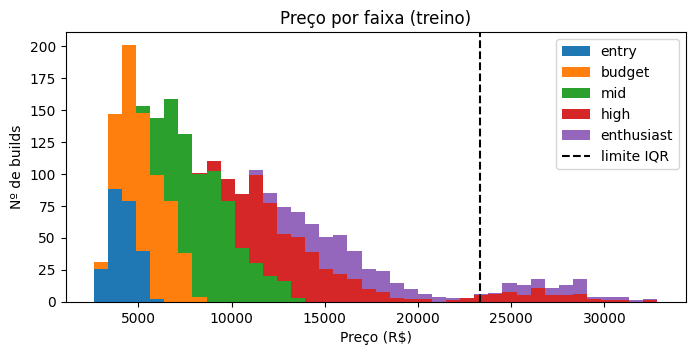

In [4]:
eda = ml.resumo_eda(X_tr, y_tr, df.loc[X_tr.index, "tier"])
print("Valores nulos:", eda["nulos"])
print("Outliers (IQR):", eda["outliers_iqr"], "acima de", brl(eda["limite_superior_iqr"]),
      "→ mantidos (builds enthusiast reais)")
display(y_tr.describe().to_frame("preço (treino)"))

tr = df.loc[X_tr.index]
plt.figure(figsize=(8, 3.5))
plt.hist([tr.loc[tr.tier == t, "preco"] for t in ml.TIERS], bins=40, stacked=True, label=ml.TIERS)
plt.axvline(eda["limite_superior_iqr"], ls="--", c="k", label="limite IQR")
plt.xlabel("Preço (R$)"); plt.ylabel("Nº de builds"); plt.legend(); plt.title("Preço por faixa (treino)")
plt.show()

## 4. Modelo A — Regressão Linear Múltipla
$$\hat{y} = \beta_0 + \sum_j \beta_j x_j$$

One-Hot com `drop='first'` e categorias **ordenadas por preço**: a coluna descartada é sempre a peça mais barata.
Assim, **β₀ = build com as peças mais baratas** e **cada βⱼ = custo extra da peça j em R$**.
Sem hiperparâmetros: os β saem dos Mínimos Quadrados.

In [5]:
cv = KFold(5, shuffle=True, random_state=ml.SEED)
lin = ml.pipe_linear().fit(X_tr, y_tr)
cv_lin = -cross_val_score(ml.pipe_linear(), X_tr, y_tr, cv=cv, scoring="neg_mean_absolute_error").mean()
print("MAE na validação cruzada (treino):", brl(cv_lin))

coefs, b0 = ml.coeficientes_linear(lin)
print("β₀ aprendido:", brl(b0), "| real (peças mais baratas):",
      brl(sum(ml.preco(c, ml.itens_por_preco(c)[0]) for c in ml.COLS)))
coefs[coefs.categoria == "gpu"][["item", "extra_real", "coef"]]

MAE na validação cruzada (treino): R$ 405
β₀ aprendido: R$ 2.451 | real (peças mais baratas): R$ 2.473


,item,extra_real,coef
35,GTX 1650,0,0.00
36,RX 6600,350,329.66
37,RTX 3060 12GB,750,732.75
38,RX 7600,970,943.05
39,Arc B580,1350,"1,322.23"
40,RTX 4060,1450,"1,433.19"
41,RX 7800 XT,2550,"2,508.53"
42,RTX 5060 Ti 16GB,2933,"2,935.83"
43,RTX 4070,2950,"2,904.18"
44,RTX 5070,3413,"3,337.89"


### Prova 1 — a predição é a soma β₀ + Σβ

In [6]:
build = {"cpu": "AMD Ryzen 5 7600", "mobo": "ASUS Prime A620M-K", "ram": "DDR5 16GB 5600MHz (2x8)",
         "gpu": "RTX 4060", "ssd": "Kingston NV2 1TB", "fonte": "Corsair CX650 Bronze",
         "cooler": "DeepCool AK400", "gabinete": "Corsair 3000D Airflow"}
Xb = pd.DataFrame([build])[ml.COLS]
ref = coefs.set_index(["categoria", "item"])
tab = pd.DataFrame([{"peça": build[c], "custo extra real": ref.loc[(c, build[c])].extra_real,
                     "β aprendido": ref.loc[(c, build[c])].coef} for c in ml.COLS],
                   index=[ml.NOMES_COLS[c] for c in ml.COLS])
display(tab)
manual = b0 + tab["β aprendido"].sum()
print(f"Soma manual β₀ + Σβ = {manual:,.2f}")
print(f"lin.predict()       = {lin.predict(Xb)[0]:,.2f}")

,peça,custo extra real,β aprendido
Processador,AMD Ryzen 5 7600,452,-286.13
Placa-mãe,ASUS Prime A620M-K,95,371.68
Memória RAM,DDR5 16GB 5600MHz (2x8),260,768.34
Placa de vídeo,RTX 4060,1450,"1,433.19"
SSD,Kingston NV2 1TB,150,124.64
Fonte,Corsair CX650 Bronze,200,219.91
Cooler,DeepCool AK400,180,178.00
Gabinete,Corsair 3000D Airflow,200,228.00


Soma manual β₀ + Σβ = 5,488.43
lin.predict()       = 5,488.43


### Prova 2 — os coeficientes recuperam os preços do catálogo
GPU, SSD, fonte, cooler e gabinete caem sobre a diagonal. Processador, placa-mãe e RAM se afastam por
**multicolinearidade**: pela compatibilidade, aparecem sempre juntos (AM5 + placa AM5 + DDR5), então o
modelo aprende o custo da **plataforma**, não de cada peça isolada.

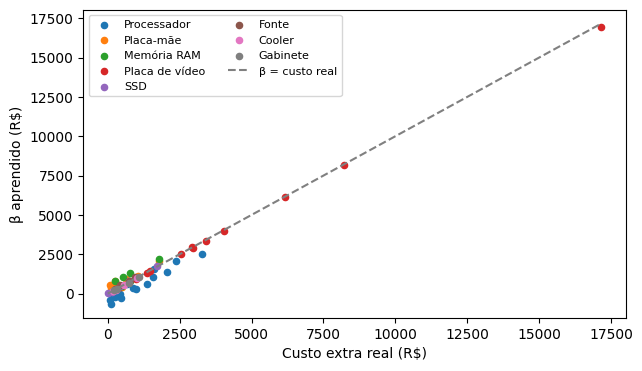

Erro médio β × real — peças independentes: R$ 44 | plataforma: R$ 364


In [7]:
c = coefs[~coefs.referencia]
plt.figure(figsize=(7, 4))
for cat in ml.COLS:
    d = c[c.categoria == cat]; plt.scatter(d.extra_real, d.coef, s=20, label=ml.NOMES_COLS[cat])
m = c.extra_real.max(); plt.plot([0, m], [0, m], "--", c="gray", label="β = custo real")
plt.xlabel("Custo extra real (R$)"); plt.ylabel("β aprendido (R$)"); plt.legend(fontsize=8, ncol=2)
plt.show()
err = (c.coef - c.extra_real).abs()
plat = c.categoria.isin(["cpu", "mobo", "ram"])
print("Erro médio β × real — peças independentes:", brl(err[~plat].mean()), "| plataforma:", brl(err[plat].mean()))

## 5. Modelo B — KNN Regressor
Não aprende equação: guarda o treino e, para uma build nova, faz a **média do preço dos K vizinhos mais próximos**.
One-Hot **completo**: cada peça diferente muda 2 colunas, então a distância entre builds que diferem em *m* peças é **√(2m)**.

K e o tipo de peso são escolhidos por **GridSearchCV** (CV de 5 dobras, só no treino).

Melhores hiperparâmetros: {'modelo__n_neighbors': 11, 'modelo__weights': 'distance'} | MAE CV: R$ 1.480


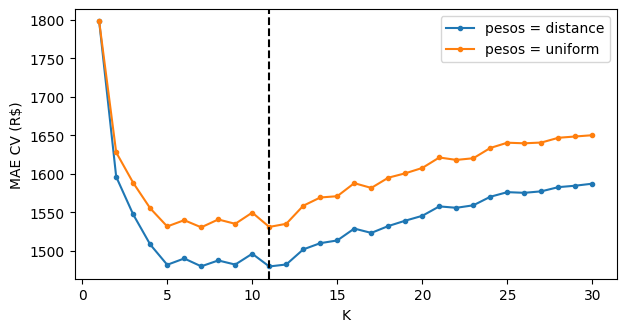

In [8]:
grid = GridSearchCV(ml.pipe_knn(), {"modelo__n_neighbors": list(range(1, 31)),
                                    "modelo__weights": ["uniform", "distance"]},
                    cv=cv, scoring="neg_mean_absolute_error").fit(X_tr, y_tr)
knn = grid.best_estimator_
print("Melhores hiperparâmetros:", grid.best_params_, "| MAE CV:", brl(-grid.best_score_))

r = grid.cv_results_
curva = pd.DataFrame({"K": r["param_modelo__n_neighbors"].astype(int),
                      "pesos": r["param_modelo__weights"].astype(str), "MAE": -r["mean_test_score"]})
plt.figure(figsize=(7, 3.5))
for p, d in curva.groupby("pesos"): plt.plot(d.K, d.MAE, "o-", ms=3, label=f"pesos = {p}")
plt.axvline(grid.best_params_["modelo__n_neighbors"], ls="--", c="k")
plt.xlabel("K"); plt.ylabel("MAE CV (R$)"); plt.legend(); plt.show()

### Prova — a predição é a média ponderada dos vizinhos

In [9]:
viz, manual = ml.vizinhos_knn(knn, X_tr, y_tr, build)
display(viz[["distancia", "n_diferentes", "difere_em", "preco", "peso"]])
print(f"Média ponderada manual = {manual:,.2f}")
print(f"knn.predict()          = {knn.predict(Xb)[0]:,.2f}")
print("Limitação: vizinhos à mesma distância custam de", brl(viz.preco.min()), "a", brl(viz.preco.max()),
      "→ a distância mede semelhança, não custo.")

,distancia,n_diferentes,difere_em,preco,peso
0,1.41,1,Placa de vídeo,"4,665.99",0.14
1,2.00,2,"Placa-mãe, SSD","5,377.03",0.10
2,2.00,2,"Placa de vídeo, Fonte","4,515.24",0.10
3,2.00,2,"Memória RAM, Gabinete","5,903.48",0.10
4,2.00,2,"Processador, Placa de vídeo","7,002.20",0.10
5,2.45,3,"Processador, Placa-mãe, Fonte","6,490.20",0.08
6,2.45,3,"Placa-mãe, SSD, Fonte","5,557.27",0.08
7,2.45,3,"Processador, Placa de vídeo, SSD","4,619.60",0.08
8,2.45,3,"Processador, Placa-mãe, Memória RAM","5,004.86",0.08
9,2.45,3,"Placa-mãe, Placa de vídeo, Gabinete","4,605.35",0.08


Média ponderada manual = 5,327.78
knn.predict()          = 5,327.78
Limitação: vizinhos à mesma distância custam de R$ 4.515 a R$ 7.002 → a distância mede semelhança, não custo.


## 6. Seleção pela validação

In [10]:
modelos = {"Linear": lin, "KNN": knn}
val = pd.DataFrame({m: ml.metricas(y_va, p.predict(X_va)) for m, p in modelos.items()}).T
display(val)
melhor = val["MAE"].idxmin()
print("Modelo escolhido (menor MAE de validação):", melhor)

,MAE,RMSE,R2,MAPE
Linear,430.56,589.38,0.99,4.16
KNN,"1,427.39","2,226.25",0.85,13.69


Modelo escolhido (menor MAE de validação): Linear


## 7. Teste — usado uma única vez
A decisão já foi tomada na validação; o teste só estima o desempenho em dados nunca vistos.

,MAE,RMSE,R2,MAPE
Linear,391.54,508.26,0.99,3.97
KNN,"1,341.60","2,021.16",0.87,12.79


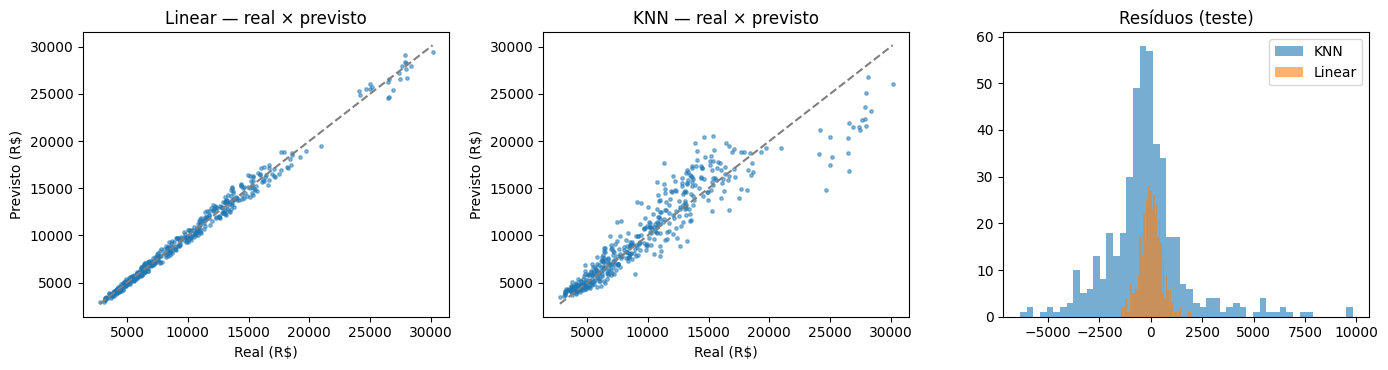

In [11]:
pred = {m: p.predict(X_te) for m, p in modelos.items()}
teste = pd.DataFrame({m: ml.metricas(y_te, p) for m, p in pred.items()}).T
display(teste)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
for a, m in zip(ax[:2], modelos):
    a.scatter(y_te, pred[m], s=6, alpha=0.5); a.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], "--", c="gray")
    a.set_title(f"{m} — real × previsto"); a.set_xlabel("Real (R$)"); a.set_ylabel("Previsto (R$)")
for m in ["KNN", "Linear"]: ax[2].hist(y_te - pred[m], bins=50, alpha=0.6, label=m)
ax[2].set_title("Resíduos (teste)"); ax[2].legend()
plt.tight_layout(); plt.show()

## 8. Conclusão
- **A Regressão Linear venceu**: o preço de um PC é aditivo, exatamente a forma que ela assume, e os β recuperam o preço das peças.
- Seu **MAPE ≈ 4%** está no piso teórico: a variação de ±8% é aleatória (desvio médio de 4%) e nenhum modelo consegue prevê-la.
- **Sem sobreajuste**: o MAE é estável entre CV, validação e teste nos dois modelos.
- O **KNN** perde por viés de representação: conta *quantas* peças diferem, não *quanto* custam.
- **Interpretabilidade**: a Linear explica globalmente (um valor em R$ por peça); o KNN explica caso a caso (pelos vizinhos).